# Import Necessary Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [4]:
import time

# Load Iris Dataset

In [5]:
#load iris dataset
iris=load_iris()

In [6]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
#convert into dataframe
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [8]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
#add target column to dataframe 
df["species"]=iris.target

In [10]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [11]:
#Replace target values with species name
df["species"]=df["species"].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
})

In [12]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


# Exploratory Data Analysis(EDA)

## Shape

In [13]:
df.shape

(150, 5)

## Datatypes

In [14]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

## Null Value Check

In [15]:
df.isnull()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [16]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## Descriptive statistics


In [17]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Information

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## No. of Species

In [19]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Visualisations

## Pair Plot

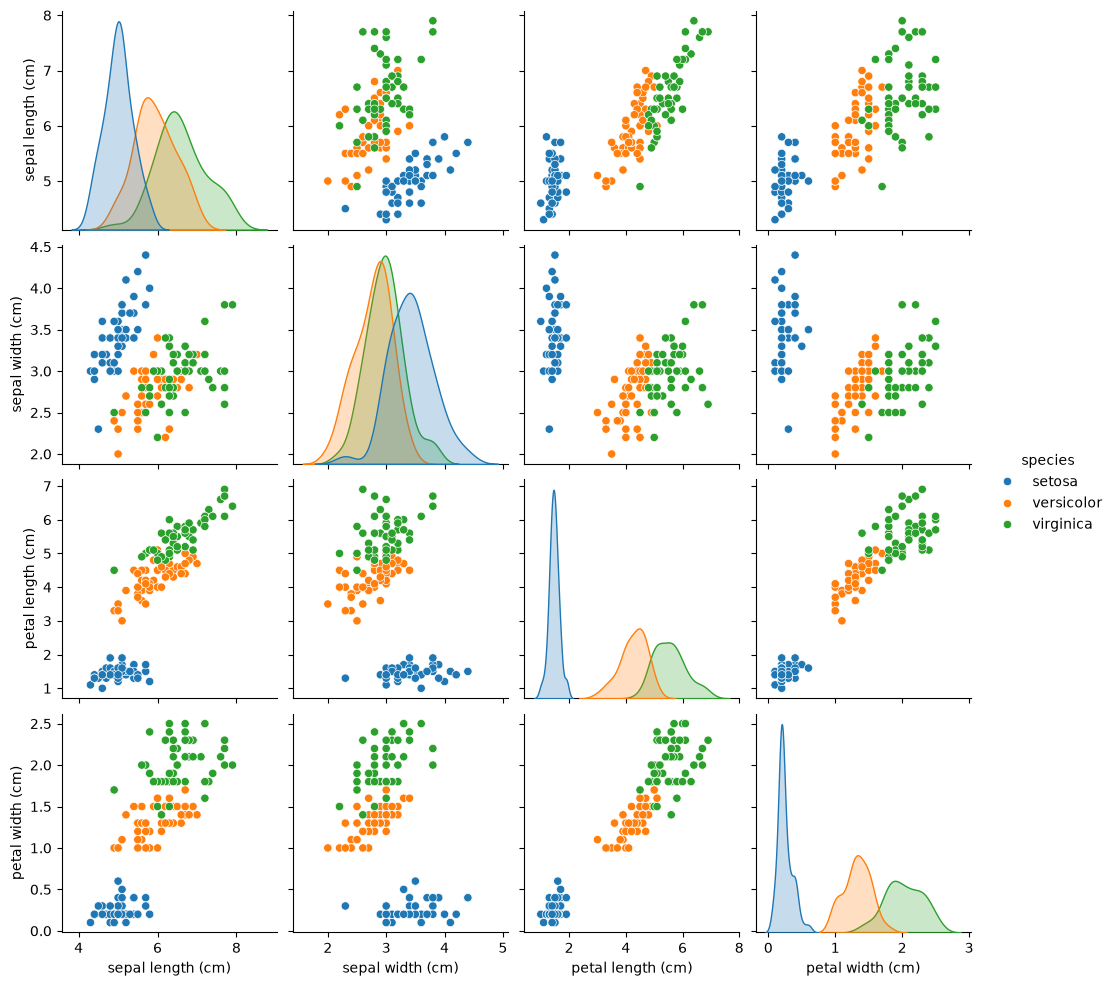

In [20]:
sns.pairplot(df,hue="species")

## Box Plot

In [21]:
features=df.columns[:-1]

In [22]:
features

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

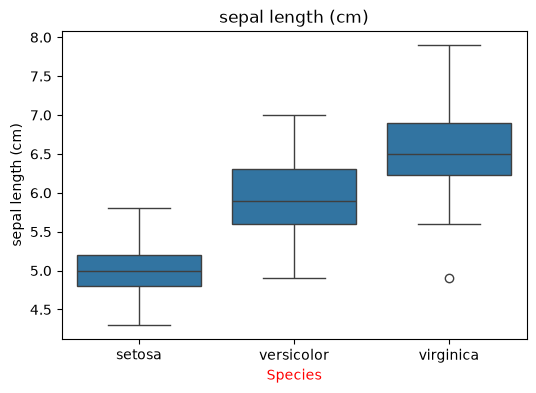

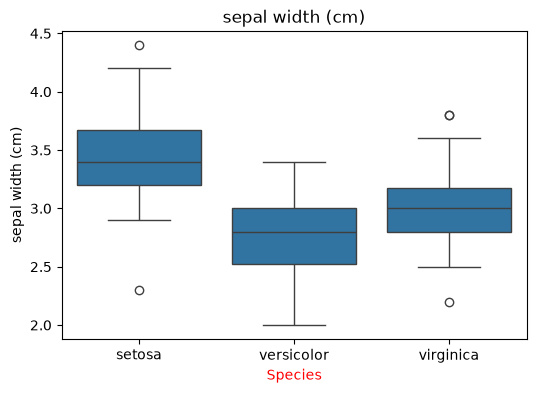

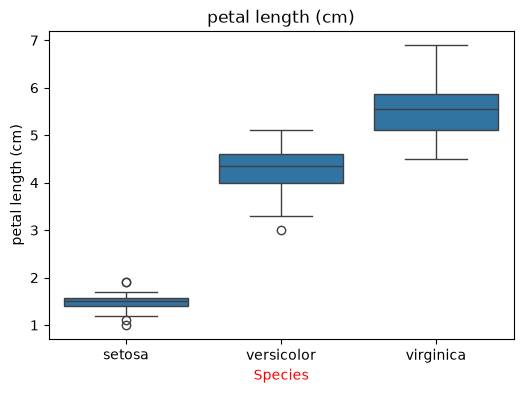

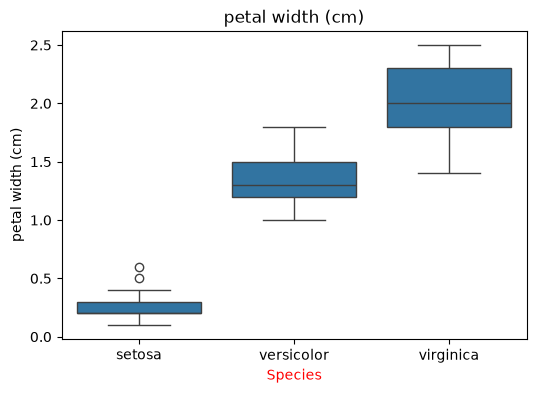

In [23]:
for feature in features :
    plt.figure(figsize=(6,4))
    sns.boxplot(x="species",y=feature,data=df,)
    plt.title(feature)
    plt.xlabel("Species",c="r")
    plt.show()

## Correlation Heatmap

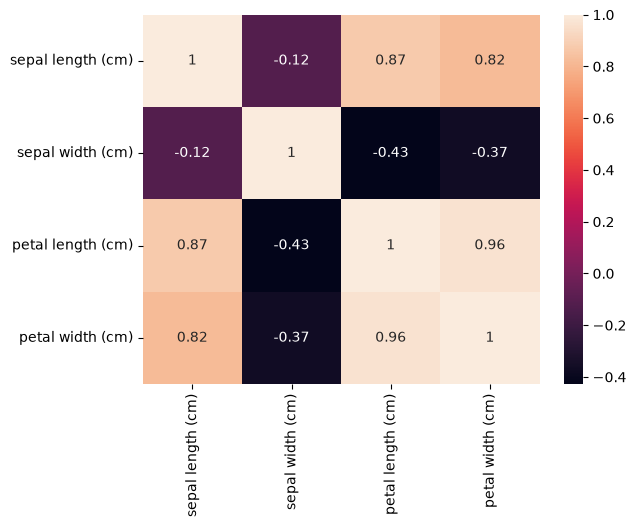

In [24]:
sns.heatmap(df.drop("species",axis=1).corr(),annot=True)
plt.show()

#  Feature selection

### Observation

From the pairplot and boxplots:

Petal Length <br>
Petal Width

are the most discriminative features because:<br>

Setosa is clearly separated.<br>
Virginica has larger petals.<br>
Versicolor lies between the two.<br>

Sepal measurements overlap more.

Therefore,

Petal Length and Petal Width contribute the most to classification.

# Prepare Data

In [25]:
x=iris.data
y=iris.target

# Train-Test Split


In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
x_train

array([[4.6, 3.6, 1. , 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.7, 3.1, 4.4, 1.4],
       [4.8, 3.4, 1.6, 0.2],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 2.5, 5. , 1.9],
       [6.4, 3.2, 4.5, 1.5],
       [5.2, 3.5, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.2, 4.1, 1.5, 0.1],
       [5.8, 2.7, 5.1, 1.9],
       [6. , 3.4, 4.5, 1.6],
       [6.7, 3.1, 4.7, 1.5],
       [5.4, 3.9, 1.3, 0.4],
       [5.4, 3.7, 1.5, 0.2],
       [5.5, 2.4, 3.7, 1. ],
       [6.3, 2.8, 5.1, 1.5],
       [6.4, 3.1, 5.5, 1.8],
       [6.6, 3. , 4.4, 1.4],
       [7.2, 3.6, 6.1, 2.5],
       [5.7, 2.9, 4.2, 1.3],
       [7.6, 3. , 6.6, 2.1],
       [5.6, 3. , 4.5, 1.5],
       [5.1, 3.5, 1.4, 0.2],
       [7.7, 2.8, 6.7, 2. ],
       [5.8, 2.7, 4.1, 1. ],
       [5.2, 3.4, 1.4, 0.2],
       [5. , 3.5, 1.3, 0.3],
       [5.1, 3.8, 1.9, 0.4],
       [5. , 2. , 3.5, 1. ],
       [6.3, 2.7, 4.9, 1.8],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [5.6, 2

In [28]:
x_test

array([[6.1, 2.8, 4.7, 1.2],
       [5.7, 3.8, 1.7, 0.3],
       [7.7, 2.6, 6.9, 2.3],
       [6. , 2.9, 4.5, 1.5],
       [6.8, 2.8, 4.8, 1.4],
       [5.4, 3.4, 1.5, 0.4],
       [5.6, 2.9, 3.6, 1.3],
       [6.9, 3.1, 5.1, 2.3],
       [6.2, 2.2, 4.5, 1.5],
       [5.8, 2.7, 3.9, 1.2],
       [6.5, 3.2, 5.1, 2. ],
       [4.8, 3. , 1.4, 0.1],
       [5.5, 3.5, 1.3, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.1, 3.8, 1.5, 0.3],
       [6.3, 3.3, 4.7, 1.6],
       [6.5, 3. , 5.8, 2.2],
       [5.6, 2.5, 3.9, 1.1],
       [5.7, 2.8, 4.5, 1.3],
       [6.4, 2.8, 5.6, 2.2],
       [4.7, 3.2, 1.6, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [5. , 3.4, 1.6, 0.4],
       [6.4, 2.8, 5.6, 2.1],
       [7.9, 3.8, 6.4, 2. ],
       [6.7, 3. , 5.2, 2.3],
       [6.7, 2.5, 5.8, 1.8],
       [6.8, 3.2, 5.9, 2.3],
       [4.8, 3. , 1.4, 0.3],
       [4.8, 3.1, 1.6, 0.2]])

## Training Testing Dataset Size

In [29]:
x_train.shape

(120, 4)

In [30]:
x_test.shape

(30, 4)

In [31]:
y_train.shape

(120,)

In [32]:
y_test.shape

(30,)

# Logistic Regression

In [33]:
start_time=time.time()
lr = LogisticRegression(max_iter=200)
lr.fit(x_train,y_train)
end_time=time.time()

In [34]:
predict_start_time=time.time()
pred_lr=lr.predict(x_test)
predict_end_time=time.time()

In [35]:
training_time=end_time-start_time
prediction_time=predict_end_time-predict_start_time
total_time_lr=training_time+prediction_time
print("Training Time : ",training_time)
print("Prediction Time : ",prediction_time)
print("Total Time : ",total_time_lr)

Training Time :  0.08689522743225098
Prediction Time :  0.0008366107940673828
Total Time :  0.08773183822631836


In [36]:
print("Accuracy : ",accuracy_score(y_test,pred_lr))

Accuracy :  1.0


In [37]:
cfm=confusion_matrix(y_test,pred_lr)
cfm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

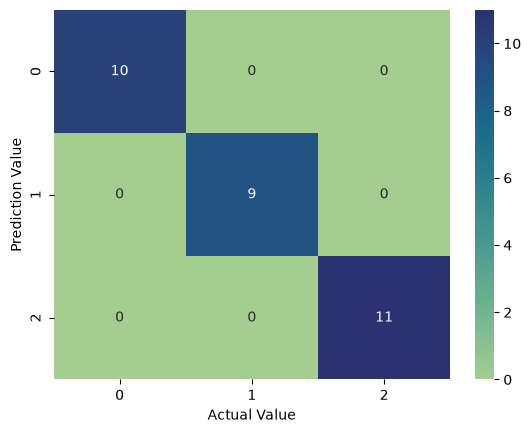

In [38]:
sns.heatmap(cfm,annot=True,cmap="crest")
plt.xlabel("Actual Value")
plt.ylabel("Prediction Value")
plt.show()

In [39]:
print(classification_report(y_test,pred_lr,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# K-Nearest Neighbours

In [40]:
start_time=time.time()
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
end_time=time.time()

In [41]:
predict_start_time=time.time()
pred_knn=knn.predict(x_test)
predict_end_time=time.time()

In [42]:
training_time=end_time-start_time
prediction_time=predict_end_time-predict_start_time
total_time_knn=training_time+prediction_time
print("Training Time : ",training_time)
print("Prediction Time : ",prediction_time)
print("Total Time : ",total_time_knn)

Training Time :  0.0021691322326660156
Prediction Time :  0.0054357051849365234
Total Time :  0.007604837417602539


In [43]:
print("Acuracy : ",accuracy_score(y_test,pred_knn))

Acuracy :  1.0


In [44]:
cfm=confusion_matrix(y_test,pred_knn)
cfm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

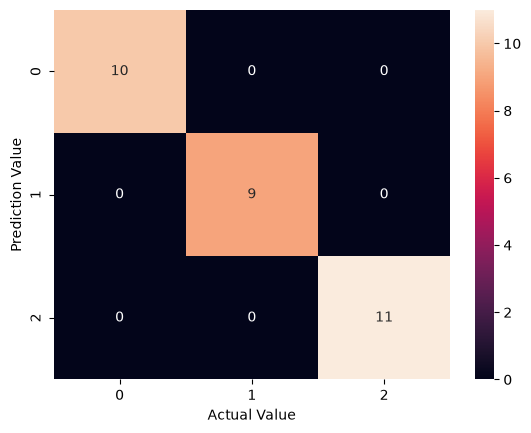

In [45]:
sns.heatmap(cfm,annot=True,)
plt.xlabel("Actual Value")
plt.ylabel("Prediction Value")
plt.show()

In [46]:
c_report=classification_report(y_test,pred_knn,target_names=iris.target_names)
print(c_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#  Decision Tree

In [47]:
start_time=time.time()
dtree=DecisionTreeClassifier(random_state=42)
dtree.fit(x_train,y_train)
end_time=time.time()

In [48]:
predict_start_time=time.time()
pred_dtree=dtree.predict(x_test)
predict_end_time=time.time()

In [49]:
training_time=end_time-start_time
prediction_time=predict_end_time-predict_start_time
total_time_dtree=training_time+prediction_time
print("Training Time : ",training_time)
print("Prediction Time : ",prediction_time)
print("Total Time : ",total_time_dtree)

Training Time :  0.002922534942626953
Prediction Time :  0.0006420612335205078
Total Time :  0.003564596176147461


In [50]:
print("Acuracy : ",accuracy_score(y_test,pred_dtree))

Acuracy :  1.0


In [51]:
cfm=confusion_matrix(y_test,pred_dtree)
cfm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

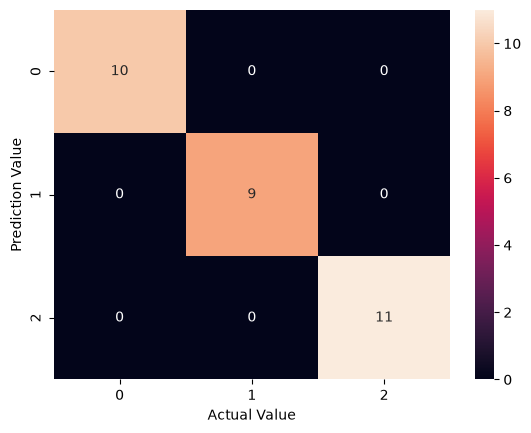

In [52]:
sns.heatmap(cfm,annot=True,)
plt.xlabel("Actual Value")
plt.ylabel("Prediction Value")
plt.show()

In [53]:
c_report=classification_report(y_test,pred_dtree,target_names=iris.target_names)
print(c_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Random Forest

In [54]:
start_time=time.time()
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
end_time=time.time()

In [55]:
predict_start_time=time.time()
pred_rf=rf.predict(x_test)
predict_end_time=time.time()

In [56]:
training_time=end_time-start_time
prediction_time=predict_end_time-predict_start_time
total_time_rf=training_time+prediction_time
print("Training Time : ",training_time)
print("Prediction Time : ",prediction_time)
print("Total Time : ",total_time_rf)

Training Time :  0.21802783012390137
Prediction Time :  0.023030996322631836
Total Time :  0.2410588264465332


In [57]:
print("Acuracy : ",accuracy_score(y_test,pred_rf))

Acuracy :  1.0


In [58]:
cfm=confusion_matrix(y_test,pred_rf)
cfm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

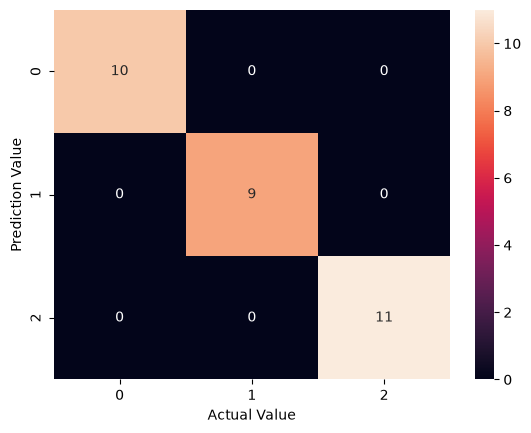

In [59]:
sns.heatmap(cfm,annot=True,)
plt.xlabel("Actual Value")
plt.ylabel("Prediction Value")
plt.show()

In [60]:
c_report=classification_report(y_test,pred_rf,target_names=iris.target_names)
print(c_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Compare Models

In [65]:
result=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ]
    ,
    "Acuraccy":[
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_dtree),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision":[
        precision_score(y_test,pred_lr,average="weighted"),
        precision_score(y_test,pred_knn,average="weighted"),
        precision_score(y_test,pred_dtree,average="weighted"),
        precision_score(y_test,pred_rf,average="weighted"),
    ],
    "F1_Score":[
        f1_score(y_test,pred_lr,average="weighted"),
        f1_score(y_test,pred_knn,average="weighted"),
        f1_score(y_test,pred_dtree,average="weighted"),
        f1_score(y_test,pred_rf,average="weighted"),
    ],
    "Recall":[
        recall_score(y_test,pred_lr,average="weighted"),
        recall_score(y_test,pred_knn,average="weighted"),
        recall_score(y_test,pred_dtree,average="weighted"),
        recall_score(y_test,pred_rf,average="weighted"),
    ],
    "Time_Taken":[
        total_time_lr,
        total_time_knn,
        total_time_dtree,
        total_time_rf
    ]
    })

In [66]:
result

,Model,Acuraccy,Precision,F1_Score,Recall,Time_Taken
0,Logistic Regression,1.0,1.0,1.0,1.0,0.087732
1,KNN,1.0,1.0,1.0,1.0,0.007605
2,Decision Tree,1.0,1.0,1.0,1.0,0.003565
3,Random Forest,1.0,1.0,1.0,1.0,0.241059


# Highlight the Best Model

In [71]:
best_model=result.sort_values(by=["Acuraccy","F1_Score","Time_Taken"],ascending=[False,False,True])

In [72]:
best_model

,Model,Acuraccy,Precision,F1_Score,Recall,Time_Taken
2,Decision Tree,1.0,1.0,1.0,1.0,0.003565
1,KNN,1.0,1.0,1.0,1.0,0.007605
0,Logistic Regression,1.0,1.0,1.0,1.0,0.087732
3,Random Forest,1.0,1.0,1.0,1.0,0.241059


### The "Decision Tree" is the best suitable model 

In [77]:
print("The Best Model is :\n",best_model.head(1))

The Best Model is :
            Model  Acuraccy  Precision  F1_Score  Recall  Time_Taken
2  Decision Tree       1.0        1.0       1.0     1.0    0.003565


#### Comparison plot between different Models

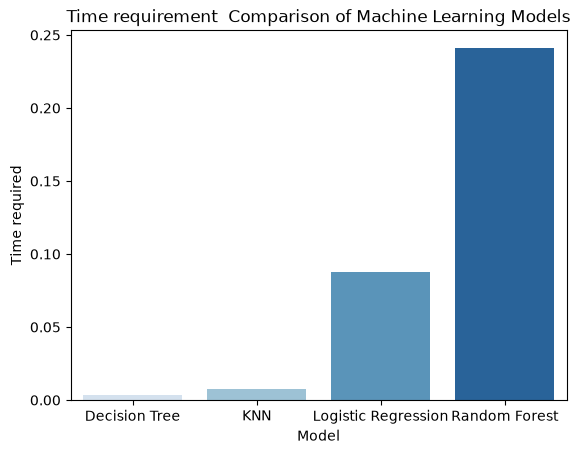

In [89]:
sns.barplot(x=best_model.Model,
           y=best_model.Time_Taken,
           palette="Blues",
           hue=best_model.Model)

plt.title("Time requirement  Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Time required")

plt.show()

# Conclusion